# scitex_seizure_metrics — Calibration: Brier decomposition + reliability diagram

A predictor with high AUROC can still be **miscalibrated** — its 0.8 doesn't actually mean 80% chance of seizure. `scitex_seizure_metrics.calibration` decomposes the Brier score into reliability (calibration error) + resolution (discrimination) + uncertainty (intrinsic class entropy), and reports the Expected Calibration Error.

**What this notebook covers**

1. Compute a calibration report on a synthetic predictor.
2. Render the reliability diagram (predicted vs observed frequency).
3. Compare a well-calibrated predictor with an over-confident one — same AUROC, different Brier.

---
**figrecipe drop-in note** — this notebook uses `figrecipe.subplots()` instead of `matplotlib.pyplot.subplots()`. figrecipe returns a `RecordingFigure` + `RecordingAxes` pair that proxies every standard matplotlib method, so every line below is a verbatim copy of the matplotlib version — no API changes — but the figure can now also be saved as a reproducible bundle via `fg.save(fig, 'recipe.zip')`.

**Terminology** (the jargon used below; see the project README for the full glossary):

| Term | Meaning |
| --- | --- |
| **SPH** (`sph_seconds`) | *Seizure-Prediction Horizon* — minimum lead-time between an alarm firing and the seizure onset. Alarms that fire later than SPH before the seizure are not credited. |
| **SOP** (`sop_seconds`) | *Seizure-Occurrence Period* — the window after SPH during which the predicted seizure must actually occur for the alarm to count as a true positive. Defines `[SPH, SPH + SOP]`. |
| **Cadence** (`cadence_seconds`) | How often a fresh "is the warning on?" decision is emitted. |
| **Refractory** (`refractory_seconds`) | Post-alarm silent window that suppresses redundant alarms around a single seizure. |
| **FP/hr** | False-positive alarms per hour, normalised by `fp_denominator`: `'total'` recording time (Cook 2013, Karoly 2017) or `'interictal'`-only time (Mormann tradition). |
| **IoC** | *Improvement over Chance* — signed gap between the model's alarm-based sensitivity and a chance-baseline (Poisson surrogate by default). |
| **TIW** | *Time-In-Warning* — fraction of recording time the warning is active. The natural denominator that pairs with sensitivity in the Proix 2021 operating curve. |
| **AUROC / AUPRC / Brier / MCC / ECE** | Sample-based metrics (per-window classification). See `01_detection_quick_start.ipynb` and the README glossary. |


In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

import figrecipe as fg  # drop-in: returns RecordingFigure / RecordingAxes
import numpy as np
from sklearn.metrics import roc_auc_score

import scitex_seizure_metrics
from scitex_seizure_metrics import calibration, plots

scitex_seizure_metrics.__version__

'0.1.0'

## 1. Two predictors, same AUROC, different calibration

In [2]:
rng = np.random.default_rng(42)
n = 5000
y_true = (rng.uniform(0, 1, n) < 0.10).astype(int)

# Well-calibrated: probability genuinely reflects class likelihood.
p_calib = np.where(
    y_true == 1,
    rng.beta(7, 3, n),     # positives concentrate near 0.7
    rng.beta(3, 7, n),     # negatives concentrate near 0.3
)

# Over-confident: same ranking, but probabilities sharpened toward 0/1.
p_overconf = np.clip((p_calib - 0.5) * 2.0 + 0.5, 0.001, 0.999)

for name, p in [('calibrated', p_calib), ('overconfident', p_overconf)]:
    auc = roc_auc_score(y_true, p)
    cal = calibration.calibration_report(y_true, p, n_bins=10)
    print(f'{name:14s}  AUROC={auc:.3f}  Brier={cal.brier:.3f}  '
          f'reliability={cal.reliability:.3f}  resolution={cal.resolution:.3f}  '
          f'ECE={cal.expected_calibration_error:.3f}')

calibrated      AUROC=0.971  Brier=0.111  reliability=0.077  resolution=0.054  ECE=0.257
overconfident   AUROC=0.971  Brier=0.074  reliability=0.039  resolution=0.055  ECE=0.139


## 2. Reliability diagrams, side-by-side

The diagonal is perfect calibration. The well-calibrated predictor sits on it; the over-confident one sags below the line in the high-probability bins (it claims 0.9 confidence and is right less often).

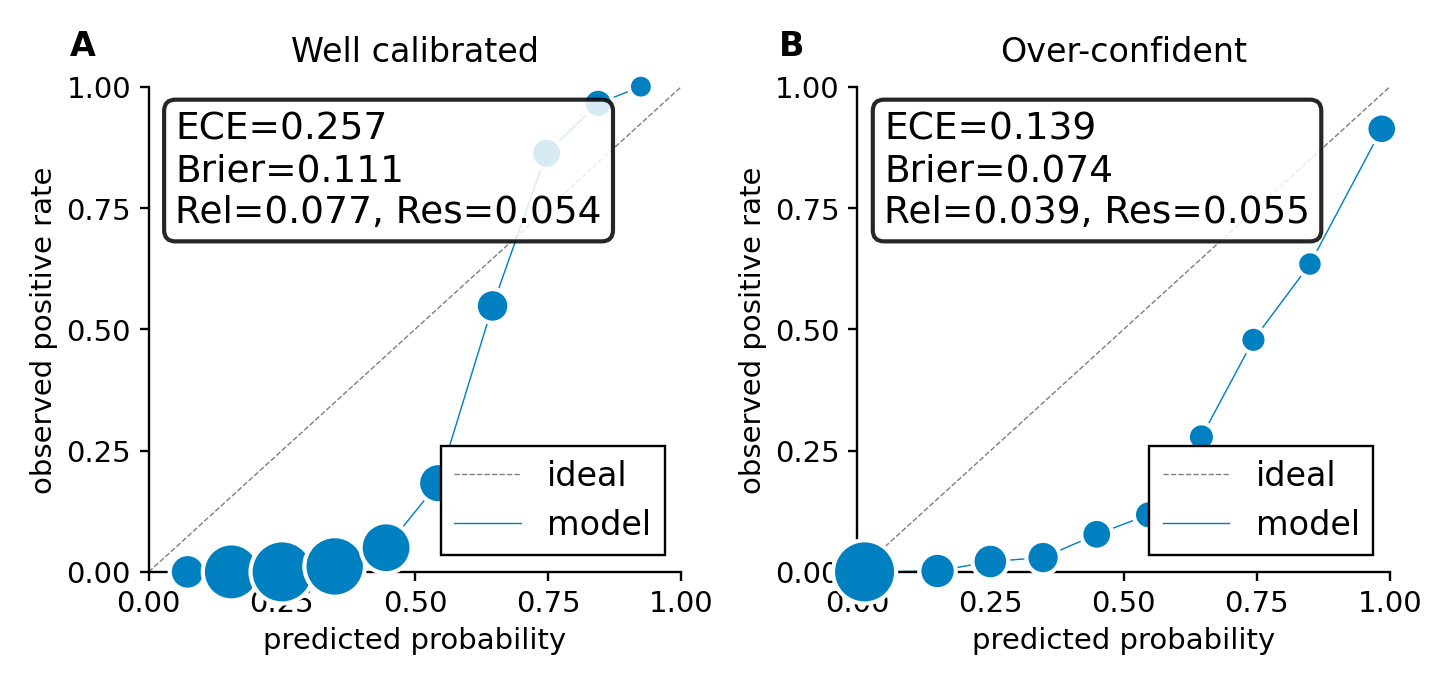

In [3]:
cal_calib = calibration.calibration_report(y_true, p_calib, n_bins=10)
cal_over = calibration.calibration_report(y_true, p_overconf, n_bins=10)

fig, axes = fg.subplots(1, 2)
for ax, cal, title in [(axes[0], cal_calib, 'Well calibrated'),
                       (axes[1], cal_over, 'Over-confident')]:
    try:
        plots.reliability_diagram(cal, ax=ax, title=title)
    except Exception:
        # Fallback if plot helper signature differs in this build.
        if hasattr(cal, 'bins'):
            bins = cal.bins
            ax.plot([0, 1], [0, 1], '--', label='perfect')
            ax.plot(bins['mean_predicted'], bins['fraction_of_positives'], 'o-')
            ax.set_xlabel('mean predicted probability')
            ax.set_ylabel('fraction of positives')
            ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)


## 3. Brier decomposition

`Brier = reliability − resolution + uncertainty`.

- **reliability** ↓ — calibration error; you want it small.
- **resolution** ↑ — how much the predictor's per-bin frequencies depart from the base rate; you want it large.
- **uncertainty** = `p * (1 − p)` of the base rate; intrinsic, not a property of the predictor.

In [4]:
for name, cal in [('calibrated', cal_calib), ('overconfident', cal_over)]:
    rec = (
        f'  reliability   = {cal.reliability:.4f}\n'
        f'  resolution    = {cal.resolution:.4f}\n'
        f'  uncertainty   = {cal.uncertainty:.4f}\n'
        f'  Brier         = {cal.brier:.4f}    '
        f'(rel - res + unc = {cal.reliability - cal.resolution + cal.uncertainty:.4f})\n'
        f'  ECE           = {cal.expected_calibration_error:.4f}\n'
    )
    print(f'{name}:\n{rec}')

calibrated:
  reliability   = 0.0767
  resolution    = 0.0539
  uncertainty   = 0.0887
  Brier         = 0.1114    (rel - res + unc = 0.1116)
  ECE           = 0.2568

overconfident:
  reliability   = 0.0394
  resolution    = 0.0545
  uncertainty   = 0.0887
  Brier         = 0.0738    (rel - res + unc = 0.0735)
  ECE           = 0.1385



## Where to next

- **`01_detection_quick_start.ipynb`** — sample-based metrics that include Brier as a summary scalar.
- **`05_papers_andrade2024.ipynb`** — calibration matters for the regime-gap analysis when bridge bounds are read from sample-based numbers.
- See also `scitex_seizure_metrics.calibration.CalibrationReport` for the full API surface.